<a href="https://colab.research.google.com/github/minoshim/Num_Analysis/blob/main/FDS/Py/Poisson/fds_poi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

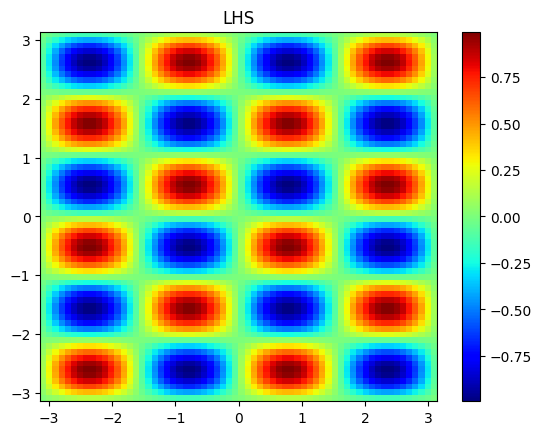

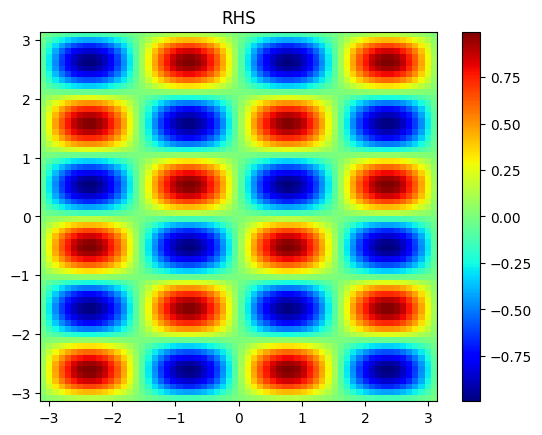

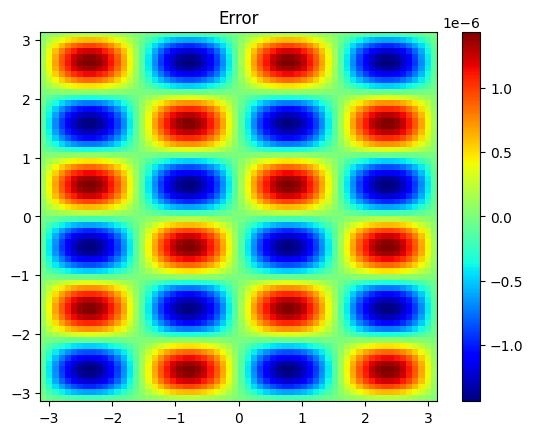

1.43831678078854e-06


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# User-set parameters
## Spatial grid
xoff=2
yoff=2
xmesh=64
ymesh=64
nx=xmesh+2*xoff
ny=ymesh+2*yoff
## Domain size
lx=2.0*np.pi
ly=2.0*np.pi
## Control parameters in Poisson solver
eps=1e-6           # Threshold for convergence
itmax=8192         # maximum number of iterations
omegaj=2.0/3.0      # Factor in weighted Jacobi method (def. = 2.0/3.0)

# Grid width
dx=lx/xmesh
dy=ly/ymesh
# Variables
x=np.zeros(nx)
y=np.zeros(ny)
f=np.zeros((ny,nx))
rhs=np.zeros((ny,nx))
d2f=np.zeros((ny,nx))
err=np.zeros((ny,nx))

# Functions
def init(x,y,f,rhs):                   # Initialize
    ny,nx=f.shape
    i=np.arange(nx)
    j=np.arange(ny)
    x[:]=(i+0.5-xoff)*dx-0.5*lx
    y[:]=(j+0.5-yoff)*dy-0.5*ly
    f[:,:]=0
    rhs[:,:]=np.sin(2*x[None,:])*np.sin(3*y[:,None]) # Right hand side
    # Test for random source term
    #rng=np.random.default_rng()
    #rhs[:,:]=rng.random((ny,nx))-0.5 #[-0.5,0.5]

def bc2d(f,xoff,yoff,dnx=0,dny=0): # Boundary condition
    # f : shape (ny,nx)
    # dnx, dny: 0 (periodic), +-1 (free of fix)
    ny, nx = f.shape
    # ---- x direction ----
    if dnx == 0:
        f[:, :xoff]      = f[:, nx-2*xoff:nx-xoff]
        f[:, nx-xoff:]   = f[:, xoff:2*xoff]
    elif abs(dnx) == 1:
        f[:, :xoff] = dnx * f[:, xoff:2*xoff][:, ::-1] # Left
        f[:, nx-xoff:] = dnx * f[:, nx-2*xoff:nx-xoff][:, ::-1] # Right
    # ---- y direction ----
    if dny == 0:
        f[:yoff, :]      = f[ny-2*yoff:ny-yoff, :]
        f[ny-yoff:, :]   = f[yoff:2*yoff, :]
    elif abs(dny) == 1:
        f[:yoff, :] = dny * f[yoff:2*yoff, :][::-1, :] # Bottom
        f[ny-yoff:, :] = dny * f[ny-2*yoff:ny-yoff, :][::-1, :] # Top

def lap2d(f,dx,dy):
    # Calculate 2D laplacian with central difference
    ny,nx=f.shape
    dx2=dx*dx
    dy2=dy*dy
    ans=np.zeros_like(f)
    ans[yoff:ny-yoff,xoff:nx-xoff]=(+(f[yoff:ny-yoff,xoff+1:nx-xoff+1]+f[yoff:ny-yoff,xoff-1:nx-xoff-1]-2*f[yoff:ny-yoff,xoff:nx-xoff])/dx2
                                    +(f[yoff+1:ny-yoff+1,xoff:nx-xoff]+f[yoff-1:ny-yoff-1,xoff:nx-xoff]-2*f[yoff:ny-yoff,xoff:nx-xoff])/dy2)
    return ans

def poi2d_ja(f,rhs,dx,dy,xoff,yoff,dnx=0,dny=0,eps=1e-6,itmax=128,omega=2.0/3.0):
    # Solve 2D poisson equation d2f/dx2 + d2f/dy2 = -rhs
    # Weighted Jacobi method
    # f, rhs : shape (ny,nx)

    ny,nx=f.shape
    eps2 = eps*eps
    dx2 = dx*dx
    dy2 = dy*dy
    dxdy2 = dx2*dy2
    denom = 1.0/(2.0*(dx2+dy2))

    # Boundary condition
    bc2d(f,xoff,yoff,dnx,dny)

    resid=dxdy2*rhs[yoff:ny-yoff,xoff:nx-xoff]*denom
    anormf=np.sum(resid*resid)
    if anormf <= eps2:
        anormf = eps2

    cnt=0
    while (cnt < itmax):
        fold=f.copy()
        resid = (+dy2*(+fold[yoff:ny-yoff, xoff-1:nx-xoff-1]
                       +fold[yoff:ny-yoff, xoff+1:nx-xoff+1])
                 +dx2*(+fold[yoff-1:ny-yoff-1, xoff:nx-xoff]
                       +fold[yoff+1:ny-yoff+1, xoff:nx-xoff])
                 +dxdy2*rhs[yoff:ny-yoff, xoff:nx-xoff])*denom-fold[yoff:ny-yoff, xoff:nx-xoff]
        resid *= omega
        anorm = np.sum(resid**2)
        f[yoff:ny-yoff, xoff:nx-xoff] += resid

        # boundary condition
        bc2d(f,xoff,yoff,dnx,dny)

        cnt += 1
        if (anorm < eps2*anormf):
            break

    return np.sqrt(anorm/anormf)

if __name__ == "__main__":
    init(x,y,f,rhs)
    bc2d(rhs,xoff,yoff,0,0)
    poi2d_ja(f,rhs,dx,dy,xoff,yoff,0,0,eps,itmax,omegaj)
    d2f=lap2d(f,dx,dy)          # Left hand side
    err[yoff:-yoff,xoff:-xoff]=(d2f+rhs)[yoff:-yoff,xoff:-xoff]
    plt.imshow(d2f[yoff:-yoff,xoff:-xoff],cmap='jet',origin='lower',aspect='auto',extent=[-lx/2,lx/2,-ly/2,ly/2])
    plt.colorbar()
    plt.title('LHS')
    plt.show()
    plt.imshow(-rhs[yoff:-yoff,xoff:-xoff],cmap='jet',origin='lower',aspect='auto',extent=[-lx/2,lx/2,-ly/2,ly/2])
    plt.colorbar()
    plt.title('RHS')
    plt.show()
    plt.imshow(err[yoff:-yoff,xoff:-xoff],cmap='jet',origin='lower',aspect='auto',extent=[-lx/2,lx/2,-ly/2,ly/2])
    plt.colorbar()
    plt.title('Error')
    plt.show()
    print(np.max(np.abs(err)))